# 01 · Data quality & exploratory analysis — FreshBasket loyalty churn

**Question:** which loyalty members will stop shopping (zero transactions in Apr–Jun 2024), why, and what should we do about it?

This notebook documents every data-quality issue found in the three source tables, how each one was handled, and the
exploratory analysis that shaped the modelling approach. All logic lives in `src/` (the same code `run_pipeline.py` runs);
the notebook calls it and shows the evidence.

**Headline finding:** the CHURNED label mixes two different problems. ~80% of churners had *already stopped buying*
before April 2024 (a reporting problem, solved by a rule), while churn among members still active in Q1 is ~10% (a
genuine prediction problem). Everything downstream is reported for both groups.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 120)
from src import config as C, data_quality as dq, features as fe, analysis as an

## 1. Load the raw workbook
Every sheet has a title banner in row 1, so the real header is row 2 (`header=1`). Reading with defaults silently
produces `Unnamed: n` columns and a header row inside the data — the first data-quality trap.

In [2]:
naive = pd.read_excel(C.RAW_XLSX, sheet_name='fb Customer Profile')
print('Default read  ->', list(naive.columns[:4]), '...')
raw = dq.load_raw()
for k, d in raw.items():
    print(f'{k:9s} {d.shape}  columns: {list(d.columns)}')

Default read  -> ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'FreshBasket Loyalty: Customer Churn Prediction'] ...


profile   (2608, 10)  columns: ['CUSTOMER_ID', 'SIGNUP_DATE', 'AGE', 'GENDER', 'CITY', 'MEMBERSHIP_TIER', 'MARKETING_OPT_IN', 'PREFERRED_STORE_ID', 'PREFERRED_CATEGORY', 'HOME_STORE_PRICE_TIER']
activity  (28073, 12)  columns: ['CUSTOMER_ID', 'MONTH', 'TRANSACTIONS', 'TOTAL_SPEND', 'AVG_BASKET_VALUE', 'DISTINCT_CATEGORIES', 'PROMO_TXN_PCT', 'APP_SESSIONS', 'EMAILS_OPENED', 'COUPONS_REDEEMED', 'SUPPORT_TICKETS', 'COMPLAINT_FLAG']
label     (2605, 6)  columns: ['CUSTOMER_ID', 'OBSERVATION_END_DATE', 'LAST_PURCHASE_DATE', 'MONTHS_OBSERVED', 'INSUFFICIENT_HISTORY_FLAG', 'CHURNED']


## 2. Customer profile checks

In [3]:
p = raw['profile']
print('Exact duplicate rows:', p.duplicated().sum(), '| duplicate CUSTOMER_IDs:', p.CUSTOMER_ID.duplicated().sum())
print('Missing values:', p.isna().sum()[p.isna().sum() > 0].to_dict())
print('\nRaw MEMBERSHIP_TIER values (casing/whitespace issues):')
print(p.MEMBERSHIP_TIER.value_counts().to_dict())
print('\nRaw CITY distinct values:', p.CITY.nunique(), '->', p.CITY.str.strip().str.title().nunique(), 'after cleaning')

Exact duplicate rows: 8 | duplicate CUSTOMER_IDs: 8
Missing values: {'AGE': 78, 'GENDER': 52, 'HOME_STORE_PRICE_TIER': 130}

Raw MEMBERSHIP_TIER values (casing/whitespace issues):
{'Silver': 1423, 'Gold': 792, 'Platinum': 289, ' Silver ': 20, 'silver': 19, 'SILVER': 18, 'GOLD': 14, ' Gold ': 12, 'PLATINUM': 9, 'gold': 8, ' Platinum ': 3, 'platinum': 1}

Raw CITY distinct values: 40 -> 10 after cleaning


## 3. Monthly activity checks

In [4]:
a = raw['activity']
print('Exact duplicate rows:', a.duplicated().sum())
a1 = a.drop_duplicates()
conflict = a1[a1.duplicated(['CUSTOMER_ID', 'MONTH'], keep=False)].sort_values(['CUSTOMER_ID', 'MONTH'])
print('Conflicting duplicates (same customer-month, different values):')
display(conflict[['CUSTOMER_ID', 'MONTH', 'TRANSACTIONS', 'TOTAL_SPEND', 'AVG_BASKET_VALUE']])

Exact duplicate rows: 58
Conflicting duplicates (same customer-month, different values):


,CUSTOMER_ID,MONTH,TRANSACTIONS,TOTAL_SPEND,AVG_BASKET_VALUE
14414,501780,2024-05-01,3,116.18,38.73
16384,501780,2024-05-01,3,-116.18,38.73
15432,502065,2023-04-01,3,-70.32,23.44
26567,502065,2023-04-01,3,70.32,23.44


**Spend integrity.** `TOTAL_SPEND = TRANSACTIONS × AVG_BASKET_VALUE` holds to the cent for 99.8% of rows, which
gives an objective test for corrupted values *and* a way to repair them without throwing away the month.

In [5]:
exp = a1.TRANSACTIONS * a1.AVG_BASKET_VALUE
ratio = (a1.TOTAL_SPEND / exp.replace(0, np.nan)).round(2)
print('Rows where the identity holds (|diff| < $1):', f"{((a1.TOTAL_SPEND - exp).abs() < 1)[a1.TRANSACTIONS > 0].mean():.2%}")
bad = a1[(a1.TRANSACTIONS > 0) & ((a1.TOTAL_SPEND <= 0) | (ratio > 3))]
print('Corrupted rows:', len(bad), '| negative:', (bad.TOTAL_SPEND < 0).sum(), '| zero:', (bad.TOTAL_SPEND == 0).sum(),
      '| inflated 9-15x:', (ratio[bad.index] > 3).sum())
display(bad.assign(ratio_to_expected=ratio[bad.index]).sort_values('ratio_to_expected').head(8)
        [['CUSTOMER_ID', 'MONTH', 'TRANSACTIONS', 'AVG_BASKET_VALUE', 'TOTAL_SPEND', 'ratio_to_expected']])

Rows where the identity holds (|diff| < $1): 99.78%
Corrupted rows: 57 | negative: 24 | zero: 20 | inflated 9-15x: 13


,CUSTOMER_ID,MONTH,TRANSACTIONS,AVG_BASKET_VALUE,TOTAL_SPEND,ratio_to_expected
27627,502042,2023-04-01,2,34.21,-68.42,-1.0
27625,500117,2024-03-01,1,32.85,-32.85,-1.0
16384,501780,2024-05-01,3,38.73,-116.18,-1.0
16971,501775,2023-10-01,4,29.08,-116.30,-1.0
17125,500490,2024-04-01,1,26.34,-26.34,-1.0
13696,501481,2024-06-01,2,22.32,-44.63,-1.0
17143,501908,2023-05-01,1,31.36,-31.36,-1.0
19095,502313,2023-07-01,1,28.46,-28.46,-1.0


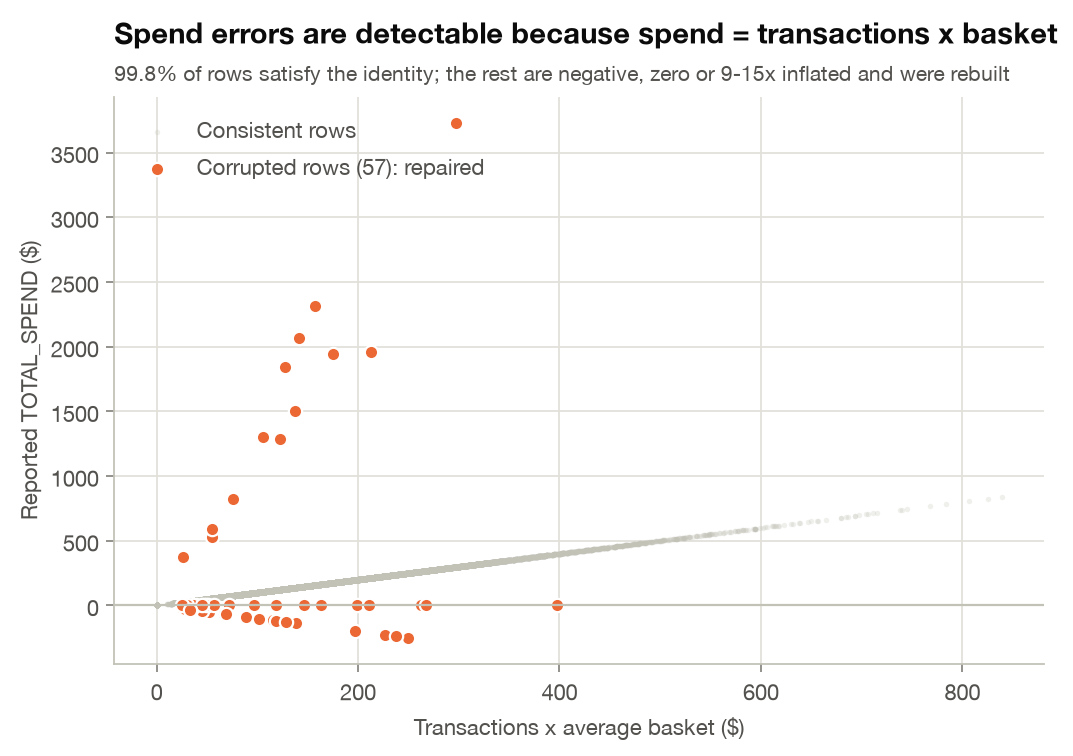

In [6]:
display(Image(an.fig_spend_repair(raw['activity'], None)))

**Zero-transaction months and missing months.** Months with 0 transactions are kept (they are a real inactivity
signal), but 1,452 of them report categories purchased and 653 report coupons redeemed, which is impossible without
a transaction, so those fields are zeroed. Separately, 953 months are simply *absent* inside members' active spans.
They are treated as **missing data, not zero activity** (the label table's `MONTHS_OBSERVED` counts them as observed,
confirming rows were lost rather than members being inactive).

In [7]:
g = a1.drop_duplicates(['CUSTOMER_ID', 'MONTH']).groupby('CUSTOMER_ID').MONTH.agg(['min', 'max', 'count'])
span = (g['max'].dt.year - g['min'].dt.year) * 12 + g['max'].dt.month - g['min'].dt.month + 1
print('Members by number of internal missing months:', (span - g['count']).value_counts().sort_index().to_dict())

Members by number of internal missing months: {0: 1825, 1: 614, 2: 131, 3: 19, 4: 5}


## 4. Label table checks and leakage audit
The target can be re-derived from the activity table (no purchase in Apr–Jun 2024, with purchases before). Agreement
is 99.7%; the 9 disagreements trace to missing activity rows, so the official label is kept.

Three label-table columns are **leaky**: they are computed over the full window *including* Apr–Jun 2024, so they
encode the answer. Churners stop generating rows, so they have fewer `MONTHS_OBSERVED`:

In [8]:
l = raw['label'].drop_duplicates()
print(l.groupby('CHURNED').MONTHS_OBSERVED.describe()[['mean', '50%']])
print('\nChurn rate by INSUFFICIENT_HISTORY_FLAG:', l.groupby('INSUFFICIENT_HISTORY_FLAG').CHURNED.mean().round(3).to_dict())
print('Members who never purchased (LAST_PURCHASE_DATE missing):', l.LAST_PURCHASE_DATE.isna().sum(), '-> all CHURNED=0, not churn-eligible')

              mean   50%
CHURNED                 
0        12.887767  17.0
1         7.596577   7.0

Churn rate by INSUFFICIENT_HISTORY_FLAG: {0: 0.297, 1: 0.418}
Members who never purchased (LAST_PURCHASE_DATE missing): 120 -> all CHURNED=0, not churn-eligible


These columns are never used as features. Leakage-safe equivalents (`history_months`, `short_history`,
`recency_months`) are rebuilt from pre-cutoff data only. `validation_design_checks.csv` shows that adding the leaky
columns would inflate Active-member PR-AUC from ~0.80 to ~0.87.

## 5. Full data-quality log
Every check, what was found and what was done (also saved as `outputs/data_quality_log.csv`).

In [9]:
profile, activity, labels, log = dq.run(save=False)
display(log)

,table,check,rows_found,action,rows_changed
0,profile,Exact duplicate rows,8,Dropped,8
1,profile,CITY: inconsistent casing / whitespace,104,Stripped and title-cased (40 raw -> 10 clean values),104
2,profile,MEMBERSHIP_TIER: inconsistent casing / whitespace,104,Stripped and title-cased (12 raw -> 3 clean values),104
3,profile,AGE missing,78,Kept as missing; median-imputed at feature time + AGE_MISSING flag,0
4,profile,AGE outside 16-100,0,None needed,0
5,profile,GENDER missing,52,Filled with explicit 'Unknown' category,52
6,profile,HOME_STORE_PRICE_TIER missing,130,Filled with explicit 'Unknown' category,130
7,profile,Signup date after data window,0,None needed,0
8,activity,Exact duplicate rows,58,Dropped,58
9,activity,"Conflicting duplicates (same customer-month, spend sign flipped)",4,Kept the row with positive spend,2


## 6. Exploratory analysis
### 6.1 A leaky bucket hidden by sign-ups

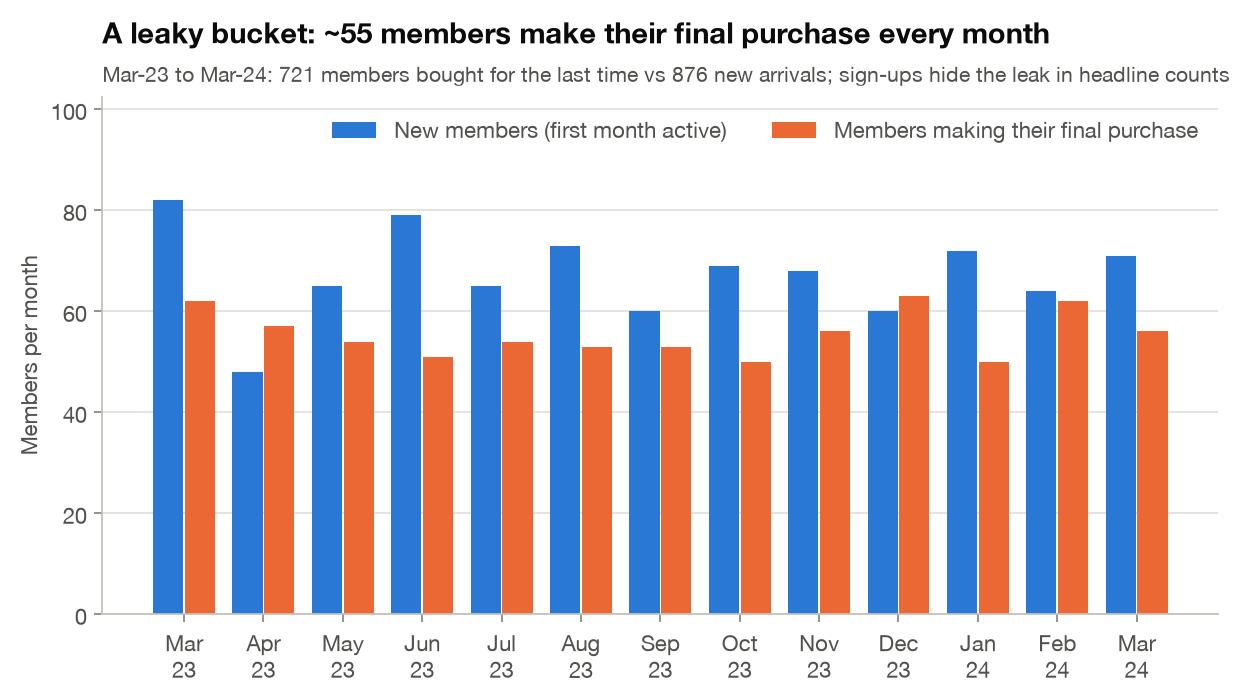

In [10]:
test = fe.build_snapshot(profile, activity, C.TEST_CUTOFF, labels)
display(Image(an.fig_leaky_bucket(activity)))

### 6.2 Two churn problems inside one label
Churn probability is a cliff in recency. Members who bought in Jan–Mar 2024 (**Active**) churn at ~10%; members already
silent for 3+ months (**Lapsed**) churn at ~99%: their "churn" happened before the label window opened.

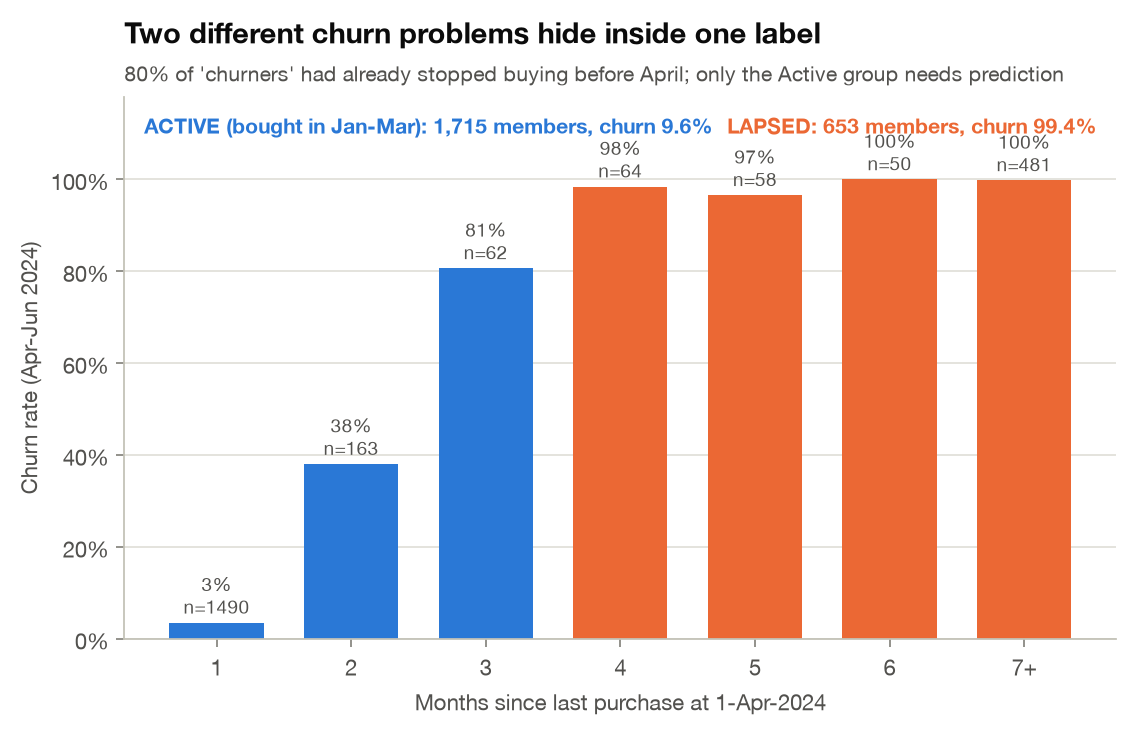

,members,churners,churn_rate,share_of_churners
segment,,,,
Active,1715,164,0.096,0.202
Lapsed,653,649,0.994,0.798


In [11]:
display(Image(an.fig_recency_cliff(test)))
seg = test.groupby('segment').churned.agg(members='size', churners='sum', churn_rate='mean')
seg['share_of_churners'] = seg.churners / seg.churners.sum()
display(seg.round(3))

### 6.3 The churn fingerprint
Aligning Active members on their last pre-April purchase shows *how* churn unfolds: transactions, app sessions and
email opens fall over the final ~2 months while support tickets spike. This is the intervention window.

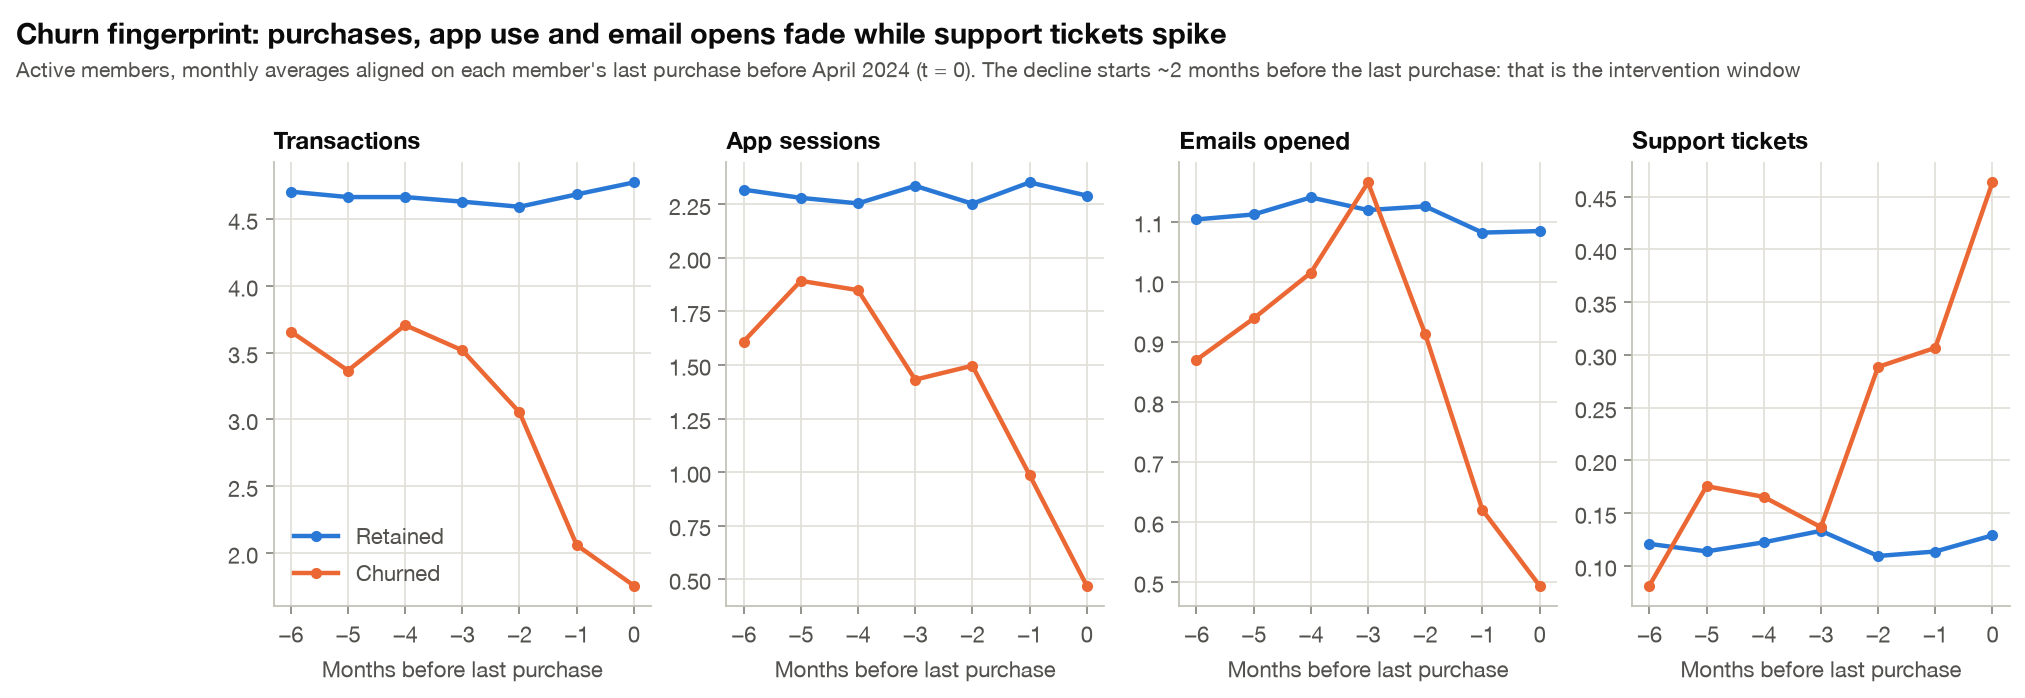

In [12]:
display(Image(an.fig_churn_fingerprint(activity, test)))

### 6.4 Engagement and support experience vs churn (Active members)

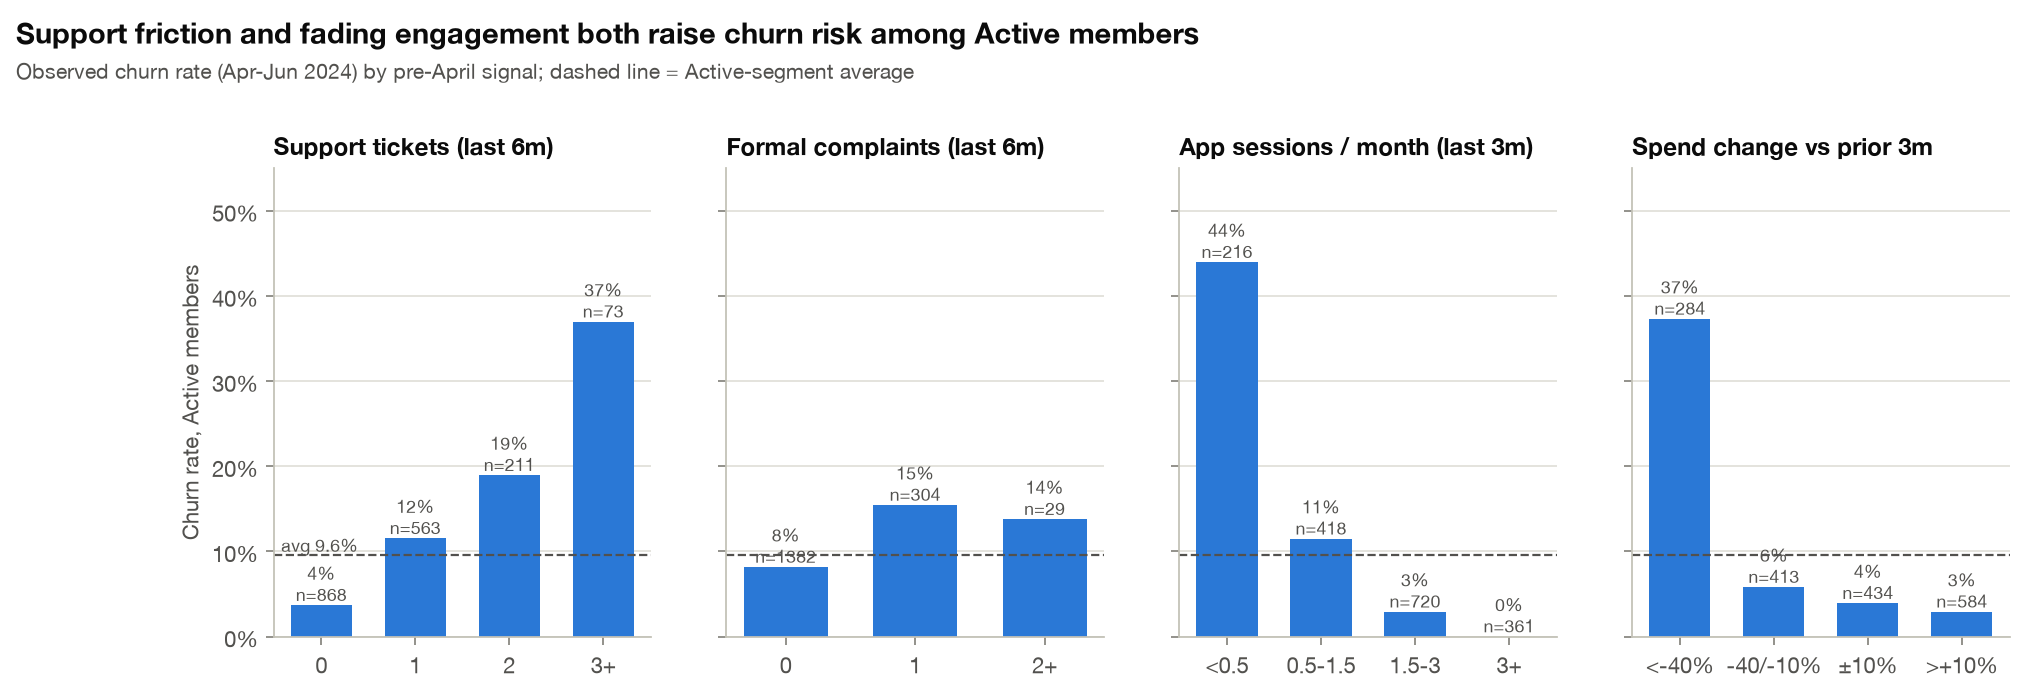

In [13]:
display(Image(an.fig_engagement_support(test)))

### 6.5 Statistical evidence
Mann–Whitney U tests (churned vs retained Active members), Benjamini–Hochberg FDR-corrected, with rank-biserial
effect size (+ = churners score higher).

In [14]:
tests = an.hypothesis_tests(test)
display(tests.round(4))
c = tests.attrs['complaint_chi2']
print(f"Chi-square, complaint in last 3m vs churn: chi2={c['chi2']:.1f}, p={c['p']:.4f}; churn {c['churn_if_complaint']:.1%} with complaint vs {c['churn_if_none']:.1%} without")

,group,feature,mean_churned,mean_retained,rank_biserial,p_value,q_value_bh,significant_5pct
1,Behavioural,txn_l3,1.3465,4.5971,-0.8411,0.0000,0.0000,True
7,Engagement,app_l3,0.5833,2.2651,-0.7532,0.0000,0.0000,True
5,Behavioural,categories_l3,1.1057,2.5724,-0.6562,0.0000,0.0000,True
2,Behavioural,txn_change_pct,-0.4082,0.1064,-0.6323,0.0000,0.0000,True
0,Behavioural,recency_months,1.9878,1.0806,0.6270,0.0000,0.0000,True
3,Behavioural,spend_change_pct,-0.3561,0.1201,-0.6232,0.0000,0.0000,True
4,Behavioural,active_months_l3,1.7683,2.6602,-0.5943,0.0000,0.0000,True
10,Engagement,coupons_l3,0.1809,0.5928,-0.5464,0.0000,0.0000,True
8,Engagement,app_change_pct,-0.4017,0.1553,-0.5081,0.0000,0.0000,True
9,Engagement,email_l3,0.4268,1.0884,-0.4865,0.0000,0.0000,True


Chi-square, complaint in last 3m vs churn: chi2=12.4, p=0.0004; churn 16.8% with complaint vs 8.6% without


### 6.6 Observed churn by tier, city and signup cohort

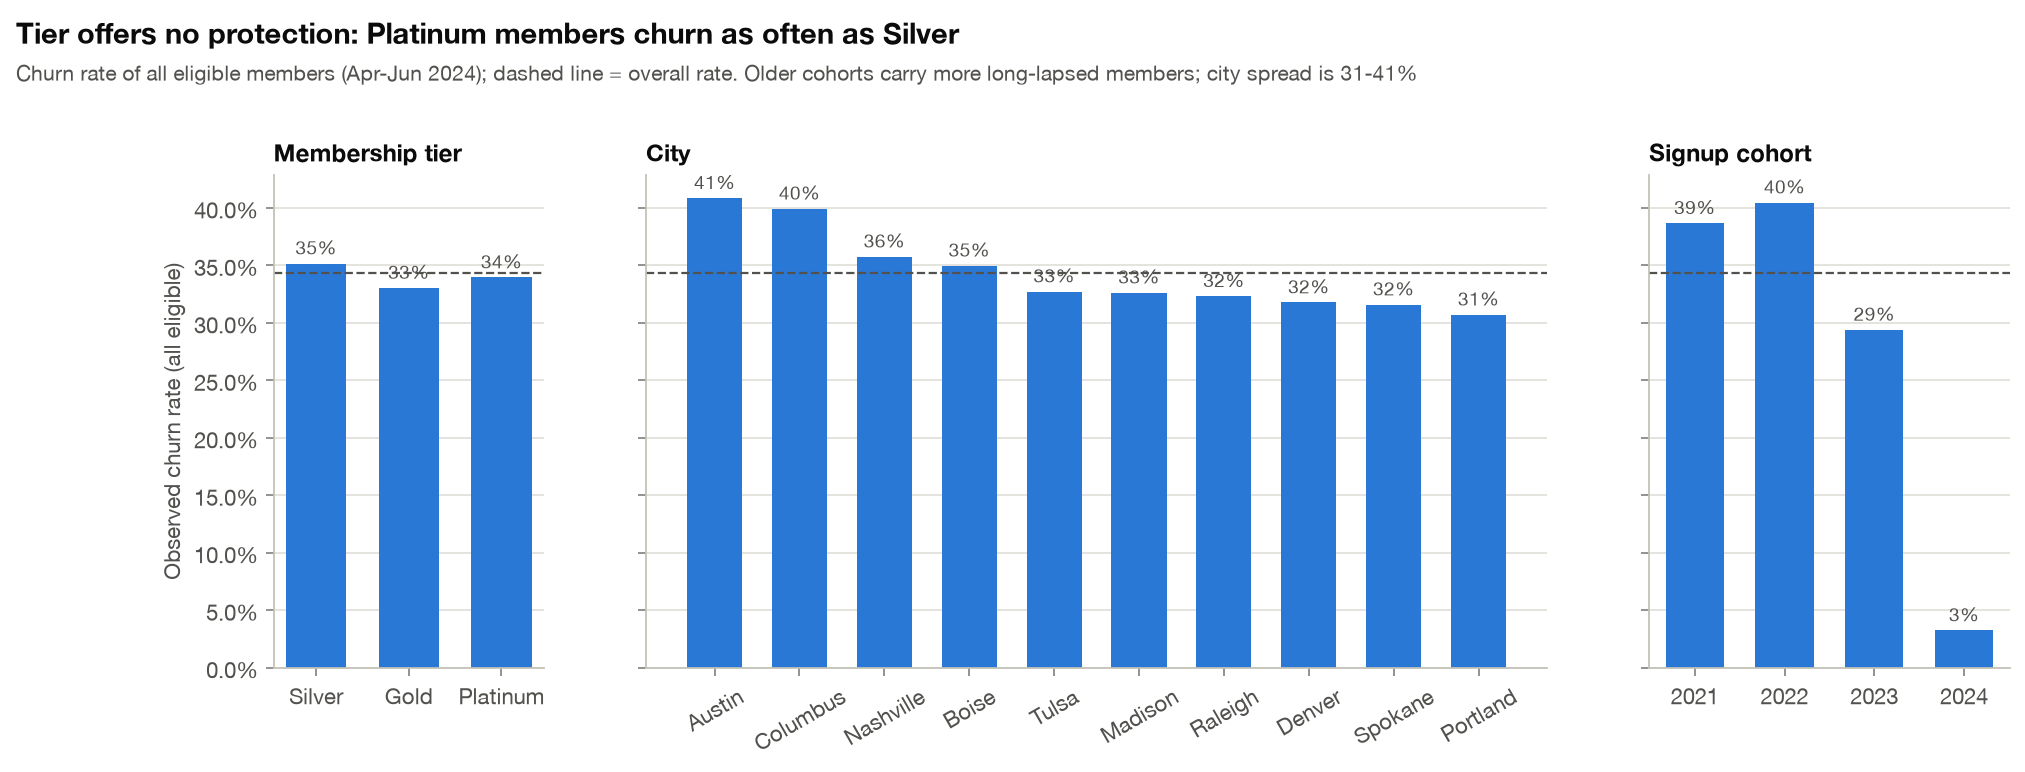

In [15]:
display(Image(an.fig_segments_observed(test)))

## 7. What this means for modelling
1. **Report everything twice**, for all eligible members and for Active members. The all-member metrics are inflated
   by easy, already-lapsed cases.
2. **Use rolling-origin snapshots.** The label definition can be replayed at earlier cut-offs (Jul-23, Oct-23, Jan-24),
   giving out-of-time training and validation data. The official Apr-24 label is the untouched test set.
3. **Features come from the 6 months before each cut-off only**: recency, 3-vs-3-month trends, engagement, support and
   history. Missing months are treated as missing data, never as zero activity.
4. **Membership tier, age and tenure carry almost no signal** (not significant after FDR correction). Behaviour,
   engagement and support do, so retention should be triggered by behaviour, not by tier.